In [ ]:
# %env MUJOCO_GL=egl
import myosuite
from myosuite.utils import gym
import numpy as np
import matplotlib.pyplot as plt
import imageio
import time
import os
import mujoco

MyoSuite:> Registering Myo Envs


/scratch/fjf33/mamba/envs/myosuite-mjx/lib/python3.13/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment myoArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/scratch/fjf33/mamba/envs/myosuite-mjx/lib/python3.13/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment myoSarcArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/scratch/fjf33/mamba/envs/myosuite-mjx/lib/python3.13/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment myoFatiArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/scratch/fjf33/mamba/envs/myosuite-mjx/lib/python3.13/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment myoArmReachRandom-v0 already in registry.
  logger.warn(f

In [2]:
from IPython.display import HTML
from base64 import b64encode

def show_video(video_path, video_width=400):

  video_file = open(video_path, "r+b").read()

  video_url = f"data:video/mp4;base64,{b64encode(video_file).decode()}"
  return HTML(f"""<video autoplay width={video_width} controls><source src="{video_url}"></video>""")


import PIL.Image, PIL.ImageDraw, PIL.ImageFont

def add_text_to_frame(frame, text, pos=(20, 20), color=(255, 0, 0), fontsize=12):
    if isinstance(frame, np.ndarray):
        frame = PIL.Image.fromarray(frame)

    draw = PIL.ImageDraw.Draw(frame)
    draw.text(pos, text, fill=color)
    return frame

# Fatigue Modeling

MyoSuite includes a fatigue model based on the (modified) ["Three Compartment Controller (3CC-r)" model](https://doi.org/10.1016/j.jbiomech.2018.06.005). \
The implementation is based on the *CumulativeFatigue* model included in the ["User-in-the-Box" framework](https://github.com/aikkala/user-in-the-box/blob/main/uitb/bm_models/effort_models.py).
For details on the dynamics of the 3CC-r model, we refer the interested readers to the papers from [Looft et al.](https://doi.org/10.1016/j.jbiomech.2018.06.005) and [Cheema et al.](https://doi.org/10.1145/3313831.3376701).

Crucially, the 3CC-r model is implemented on a muscle level, i.e., fatigue is computed for each muscle individually rather than for a single (shoulder) joint. \
While originally built and tested for models of the arm, elbow and hand, it can also be used with models of the lower extremity, e.g., the MyoLeg model.

## Use the Fatigue Model

To model fatigue, load the desired MyoSuite environment in its "Fati" variant:

In [3]:
envFatigue = gym.make('myoFatiElbowPose1D6MRandom-v0', normalize_act=False)

## for comparison
env = gym.make('myoElbowPose1D6MRandom-v0', normalize_act=False)

    MyoSuite: A contact-rich simulation suite for musculoskeletal motor control
        Vittorio Caggiano, Huawei Wang, Guillaume Durandau, Massimo Sartori, Vikash Kumar
        L4DC-2019 | https://sites.google.com/view/myosuite
    


/scratch/fjf33/mamba/envs/myosuite-mjx/lib/python3.13/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/scratch/fjf33/mamba/envs/myosuite-mjx/lib/python3.13/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


This adds the "muscle_fatigue" attribute, which entails the current fatigue state of each muscle:

In [4]:
envFatigue.unwrapped.muscle_fatigue.MF   #percentage of fatigued motor units for each muscle
envFatigue.unwrapped.muscle_fatigue.MR   #percentage of resting motor units for each muscle
envFatigue.unwrapped.muscle_fatigue.MA   #percentage of active motor units for each muscle

array([0., 0., 0., 0., 0., 0.])

The fatigue/recovery constants F and R as well as the recovery multiplier r, which determines how much faster motor units recover during rest periods (i.e., when less motor units are required than are currently active), can be set using the following methods:

In [5]:
envFatigue.unwrapped.muscle_fatigue.set_RecoveryMultiplier(10)
envFatigue.unwrapped.muscle_fatigue.set_RecoveryCoefficient(0.0022)
envFatigue.unwrapped.muscle_fatigue.set_FatigueCoefficient(0.0146)

envFatigue.unwrapped.muscle_fatigue.r, envFatigue.unwrapped.muscle_fatigue.R, envFatigue.unwrapped.muscle_fatigue.F

(10, 0.0022, 0.0146)

**Note:** The parameters F and R (and in particular their ratio, which defines the percentage of active motor units in a totally fatigued state) generally depend on the joints and muscles, and thus need to be manually chosen for each model!

The muscle force development/relaxation factors LD and LR are automatically computed for each muscle based on its time activation and deactivation constants.

#### Initial Fatigue States

By default, the simulation starts in the default "non-fatigued" muscle state with 100% resting motor units.

In [6]:
envFatigue.reset()
envFatigue.unwrapped.muscle_fatigue.MF, envFatigue.unwrapped.muscle_fatigue.MR, envFatigue.unwrapped.muscle_fatigue.MA

(array([0., 0., 0., 0., 0., 0.]),
 array([1., 1., 1., 1., 1., 1.]),
 array([0., 0., 0., 0., 0., 0.]))

To reset to a randomly chosen distribution of fatigued, resting and active motor units per muscle, the following command can be used:

In [7]:
envFatigue.unwrapped.set_fatigue_reset_random(True)

envFatigue.reset()
envFatigue.unwrapped.muscle_fatigue.MF, envFatigue.unwrapped.muscle_fatigue.MR, envFatigue.unwrapped.muscle_fatigue.MA

(array([0.4157, 0.0114, 0.2141, 0.3813, 0.6991, 0.2323]),
 array([0.53  , 0.1475, 0.177 , 0.2934, 0.0294, 0.4092]),
 array([0.0543, 0.841 , 0.6088, 0.3253, 0.2716, 0.3585]))

In the fatigue variant, the simulation applies the "currently available" muscle controls as defined by the fatigue state and dynamics, rather than the intended muscle control signals a:

In [8]:
envFatigue.unwrapped.set_fatigue_reset_random(False)
# Use the environment's action space rather than accessing a deprecated `sim` attribute
if hasattr(envFatigue, 'action_space'):
    a = np.zeros(envFatigue.action_space.shape, dtype=float)
else:
    a = np.zeros(1, dtype=float)
a[0] = 1

envFatigue.reset()
for i in range(10):
    next_o, r, done, *_, ifo = envFatigue.step(a)  # take an action

# Comparison: without fatigue
env.reset()
for i in range(10):
    next_o, r, done, *_, ifo = env.step(a)  # take an action

env.unwrapped.last_ctrl, envFatigue.unwrapped.last_ctrl, envFatigue.unwrapped.muscle_fatigue.MF


(array([1., 0., 0., 0., 0., 0.]),
 array([0.9974, 0.    , 0.    , 0.    , 0.    , 0.    ]),
 array([0.0026, 0.    , 0.    , 0.    , 0.    , 0.    ]))

This allows to predict how fatigue evolves over time:

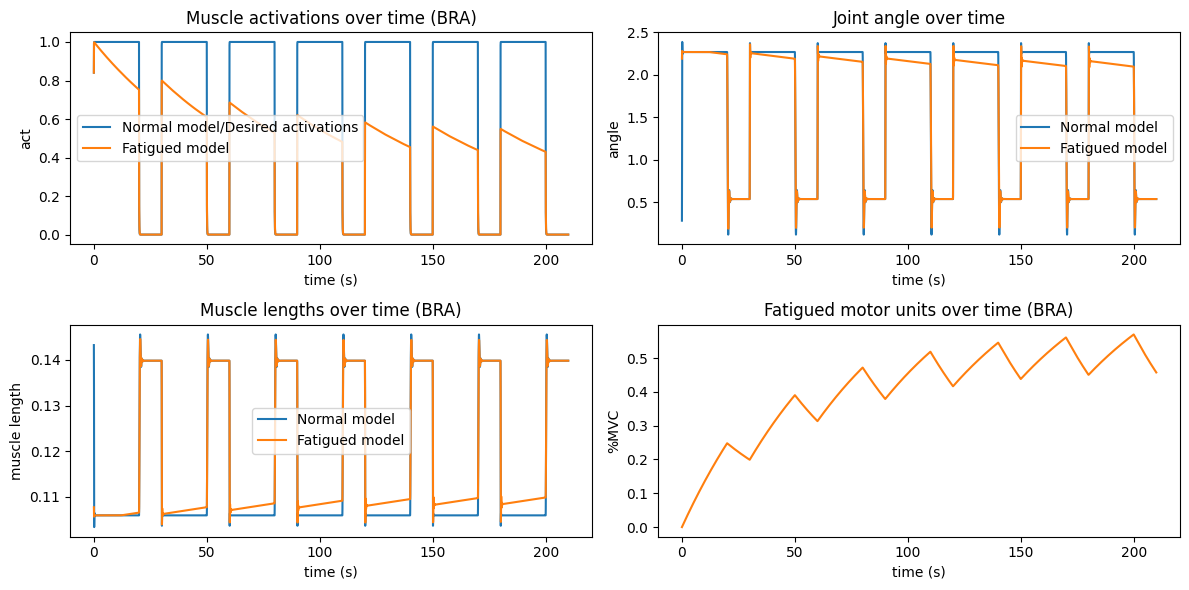

In [9]:
env.reset()
envFatigue.reset()
data_store = []
data_store_f = []
for i in range(7*3): # 7 batches of 3 episodes, with 2 episodes of maximum muscle controls for some muscles followed by a resting episode (i.e., zero muscle controls) in each batch
    a = np.zeros(env.unwrapped.mj_model.nu,)
    if i%3!=2:
        a[3:]=1
    else:
        a[:]=0

    for _ in range(500): # 500 samples (=10s) for each episode
        next_o, r, done, *_, ifo = env.step(a) # take an action
        next_f_o, r_f, done_F, *_, ifo_f = envFatigue.step(a) # take an action

        data_store.append({"action":a.copy(),
                            "jpos":env.unwrapped.mj_data.qpos.copy(),
                            "mlen":env.unwrapped.mj_data.actuator_length.copy(),
                            "act":env.unwrapped.mj_data.act.copy()})
        data_store_f.append({"action":a.copy(),
                            "jpos":envFatigue.unwrapped.mj_data.qpos.copy(),
                            "mlen":envFatigue.unwrapped.mj_data.actuator_length.copy(),
                            "MF":envFatigue.unwrapped.muscle_fatigue.MF.copy(),
                            "MR":envFatigue.unwrapped.muscle_fatigue.MR.copy(),
                            "MA":envFatigue.unwrapped.muscle_fatigue.MA.copy(),
                            "act":envFatigue.unwrapped.mj_data.act.copy()})

env.close()
envFatigue.close()

mdl = env.unwrapped.mj_model
muscle_names = [mdl.actuator(i).name for i in range(mdl.nu) if mdl.actuator_dyntype[i] == mujoco.mjtDyn.mjDYN_MUSCLE]
muscle_id = -1

plt.figure(figsize=(12, 6))
plt.subplot(221)
plt.plot(env.unwrapped.dt*np.arange(len(data_store)), np.array([d['act'][muscle_id] for d in data_store]), label="Normal model/Desired activations")
plt.plot(env.unwrapped.dt*np.arange(len(data_store)), np.array([d['act'][muscle_id] for d in data_store_f]), label='Fatigued model')
plt.legend()
plt.title(f'Muscle activations over time ({muscle_names[muscle_id]})')
plt.xlabel('time (s)'),plt.ylabel('act')

plt.subplot(222)
plt.plot(env.unwrapped.dt*np.arange(len(data_store)), np.array([d['jpos'] for d in data_store]), label="Normal model")
plt.plot(env.unwrapped.dt*np.arange(len(data_store)), np.array([d['jpos'] for d in data_store_f]), label="Fatigued model")
plt.legend()
plt.title('Joint angle over time')
plt.xlabel('time (s)'),plt.ylabel('angle')

plt.subplot(223)
plt.plot(env.unwrapped.dt*np.arange(len(data_store)), np.array([d['mlen'][muscle_id] for d in data_store]), label="Normal model")
plt.plot(env.unwrapped.dt*np.arange(len(data_store)), np.array([d['mlen'][muscle_id] for d in data_store_f]), label="Fatigued model")
plt.legend()
plt.title(f'Muscle lengths over time ({muscle_names[muscle_id]})')
plt.xlabel('time (s)'),plt.ylabel('muscle length')

plt.subplot(224)
plt.plot(env.unwrapped.dt*np.arange(len(data_store)), np.array([d['MF'][muscle_id] for d in data_store_f]), color="tab:orange")
plt.title(f'Fatigued motor units over time ({muscle_names[muscle_id]})')
plt.xlabel('time (s)'),plt.ylabel('%MVC')

plt.tight_layout()
plt.show()

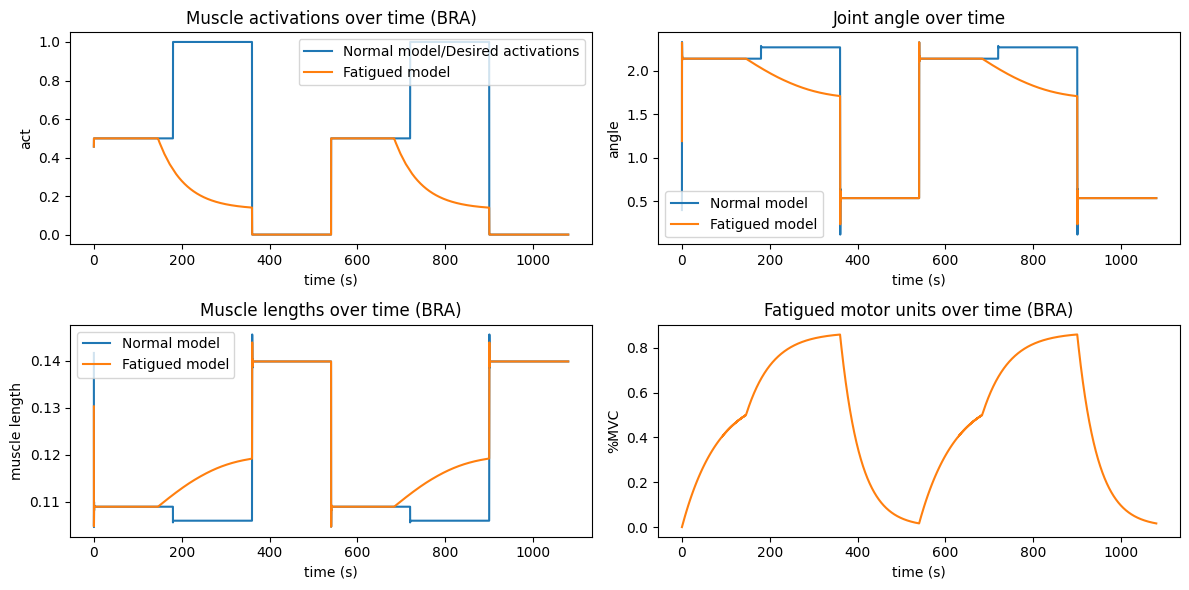

In [10]:
env.reset()
envFatigue.reset()
data_store = []
data_store_f = []
for i in range(2*3): # 2 batches of 3 episodes, with 0.5*MVC in first and 1*MVC in second episode, followed by a resting episode (i.e., zero muscle controls) in each batch
    a = np.zeros(env.unwrapped.mj_model.nu,)
    if i%3==0:
        a[3:]=0.5
    elif i%3==1:
        a[3:]=1
    else:
        a[:]=0

    for _ in range(9000): # 9000 samples (=3 minutes) for each episode
        next_o, r, done, *_, ifo = env.step(a) # take an action
        next_f_o, r_f, done_F, *_, ifo_f = envFatigue.step(a) # take an action

        data_store.append({"action":a.copy(),
                            "jpos":env.unwrapped.mj_data.qpos.copy(),
                            "mlen":env.unwrapped.mj_data.actuator_length.copy(),
                            "act":env.unwrapped.mj_data.act.copy()})
        data_store_f.append({"action":a.copy(),
                            "jpos":envFatigue.unwrapped.mj_data.qpos.copy(),
                            "mlen":envFatigue.unwrapped.mj_data.actuator_length.copy(),
                            "MF":envFatigue.unwrapped.muscle_fatigue.MF.copy(),
                            "MR":envFatigue.unwrapped.muscle_fatigue.MR.copy(),
                            "MA":envFatigue.unwrapped.muscle_fatigue.MA.copy(),
                            "act":envFatigue.unwrapped.mj_data.act.copy()})

env.close()
envFatigue.close()

mdl = env.unwrapped.mj_model
muscle_names = [mdl.actuator(i).name for i in range(mdl.nu) if mdl.actuator_dyntype[i] == mujoco.mjtDyn.mjDYN_MUSCLE]
muscle_id = -1

plt.figure(figsize=(12, 6))
plt.subplot(221)
plt.plot(env.unwrapped.dt*np.arange(len(data_store)), np.array([d['act'][muscle_id] for d in data_store]), label="Normal model/Desired activations")
plt.plot(env.unwrapped.dt*np.arange(len(data_store)), np.array([d['act'][muscle_id] for d in data_store_f]), label='Fatigued model')
plt.legend()
plt.title(f'Muscle activations over time ({muscle_names[muscle_id]})')
plt.xlabel('time (s)'),plt.ylabel('act')

plt.subplot(222)
plt.plot(env.unwrapped.dt*np.arange(len(data_store)), np.array([d['jpos'] for d in data_store]), label="Normal model")
plt.plot(env.unwrapped.dt*np.arange(len(data_store)), np.array([d['jpos'] for d in data_store_f]), label="Fatigued model")
plt.legend()
plt.title('Joint angle over time')
plt.xlabel('time (s)'),plt.ylabel('angle')

plt.subplot(223)
plt.plot(env.unwrapped.dt*np.arange(len(data_store)), np.array([d['mlen'][muscle_id] for d in data_store]), label="Normal model")
plt.plot(env.unwrapped.dt*np.arange(len(data_store)), np.array([d['mlen'][muscle_id] for d in data_store_f]), label="Fatigued model")
plt.legend()
plt.title(f'Muscle lengths over time ({muscle_names[muscle_id]})')
plt.xlabel('time (s)'),plt.ylabel('muscle length')

plt.subplot(224)
plt.plot(env.unwrapped.dt*np.arange(len(data_store)), np.array([d['MF'][muscle_id] for d in data_store_f]), color="tab:orange")
plt.title(f'Fatigued motor units over time ({muscle_names[muscle_id]})')
plt.xlabel('time (s)'),plt.ylabel('%MVC')

plt.tight_layout()
plt.show()


## Train Agents with Fatigue

In [11]:
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import CheckpointCallback

Warning: Running the following cell may take 2-5 minutes.

In [ ]:
env_name = "myoFatiElbowPose1D6MRandom-v0"

env = gym.make(env_name)
env.unwrapped.set_fatigue_reset_random(True)
env.reset()

# Save a checkpoint every 10000 steps
checkpoint_callback = CheckpointCallback(
  save_freq=10000,
  save_path=f"./{env_name}/iterations/",
  name_prefix="rl_model",
  save_replay_buffer=True,
  save_vecnormalize=True,
)

model = PPO("MlpPolicy", env, verbose=0)
model.learn(total_timesteps=200000, callback=checkpoint_callback)

**NOTE:** By default, random fatigue states are sampled at the beginning of each training episode. \
To start with a specific, fixed fatigue state, set `fatigue_reset_random=False` and define `fatigue_reset_vec` as the vector MF of fatigued motor units per muscle.

Best practice is to create a new  of the desired environment, i.e., calling `register_env_variant()` with
`variants={'muscle_condition': 'fatigue',
            'fatigue_reset_vec': np.array([0., 0., 0.]),
            'fatigue_reset_random': False}`.


## Simulate and Evaluate Trained Agents

In the following, we evaluate the latest policy trained for a given fatigue environment (and for comparison also the policy trained in the respective non-fatigue environment).

To this end, we simulate several episodes per policy, with fatigue accumulating across episodes, starting in the default zero fatigue state. \
Videos of the first and the last few episodes are generated, and simulation data is logged (and later visualised) for all episodes.

### Example 1: Fatigue

In [ ]:
env_name = "myoFatiElbowPose1D6MRandom-v0"

GENERATE_VIDEO = True
GENERATE_VIDEO_EPS = 4  #number of episodes that are rendered BOTH at the beginning (i.e., without fatigue) and at the end (i.e., with fatigue)

STORE_DATA = True  #store collected data from evaluation run in .npy file
n_eps = 250

###################################

env = gym.make(env_name)

model_path = f"{env_name}/iterations/rl_model_200000_steps.zip"
if not os.path.exists(model_path):
    print("PPO model not found; skipping evaluation. Train with 4c_Train_SB_policy or download baselines.")
    env.close()
else:
    from stable_baselines3 import PPO
model = PPO.load(f"{env_name}/iterations/rl_model_200000_steps")

env.unwrapped.set_fatigue_reset_random(False)
env.unwrapped.reset(fatigue_reset=True)  #ensure that fatigue is reset before the simulation starts

env.unwrapped.mj_model.cam_poscom0[0] = np.array([-1.3955, -0.3287,  0.6579])

data_store = []
if GENERATE_VIDEO:
    frames = []

env.unwrapped.target_jnt_value = env.unwrapped.target_jnt_range[:, 1]
env.unwrapped.target_type = 'fixed'
env.unwrapped.update_target(restore_sim=True)

start_time = time.time()
for ep in range(n_eps):
    print("Ep {} of {}".format(ep, n_eps))

    for _cstep in range(env.spec.max_episode_steps):
        if GENERATE_VIDEO and (ep in range(GENERATE_VIDEO_EPS) or ep in range(n_eps-GENERATE_VIDEO_EPS, n_eps)):
            frame = env.unwrapped.mj_renderer.render_offscreen(width=400, height=400, camera_id=0)

            # Add text overlay
            _current_time = (ep*env.spec.max_episode_steps + _cstep)*env.unwrapped.dt
            frame = np.array(add_text_to_frame(frame,
                    f"t={str(int(_current_time//60)).zfill(2)}:{str(int(_current_time%60)).zfill(2)}min",
                    pos=(285, 3), color=(0, 0, 0), fontsize=18))

            frames.append(frame)
        o = env.unwrapped.get_obs()
        a = model.predict(o)[0]
        next_o, r, done, _, ifo = env.unwrapped.step(a) # take an action based on the current observation

        data_store.append({"action":a.copy(),
                            "jpos":env.unwrapped.mj_data.qpos.copy(),
                            "mlen":env.unwrapped.mj_data.actuator_length.copy(),
                            "act":env.unwrapped.mj_data.act.copy(),
                            "reward":r,
                            "solved":env.unwrapped.rwd_dict['solved'].item(),
                            "pose_err":env.unwrapped.get_obs_dict(env.unwrapped.mj_model, env.unwrapped.mj_data)["pose_err"],
                            "MA":env.unwrapped.muscle_fatigue.MA.copy(),
                            "MR":env.unwrapped.muscle_fatigue.MR.copy(),
                            "MF":env.unwrapped.muscle_fatigue.MF.copy(),
                            "ctrl":env.unwrapped.last_ctrl.copy()})
env.close()

## OPTIONALLY: Stored simulated data
if STORE_DATA:
    os.makedirs(f"{env_name}/logs", exist_ok=True)
    np.save(f"{env_name}/logs/fatitest.npy", data_store)

## OPTIONALLY: Render video
if GENERATE_VIDEO:
    os.makedirs(f'{env_name}/videos', exist_ok=True)
    # Write frames to file
    with imageio.get_writer(f'{env_name}/videos/fatitest.mp4', fps=int(1/env.unwrapped.dt)) as video:
        for frame in frames:
            video.append_data(frame)

end_time = time.time()
print(f"DURATION: {end_time - start_time:.2f}s")

if GENERATE_VIDEO:
    display(show_video(f'{env_name}/videos/fatitest.mp4'))

/scratch/fjf33/mamba/envs/myosuite-mjx/lib/python3.13/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/scratch/fjf33/mamba/envs/myosuite-mjx/lib/python3.13/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
/scratch/fjf33/mamba/envs/myosuite-mjx/lib/python3.13/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than

Ep 0 of 250
Ep 1 of 250
Ep 2 of 250
Ep 3 of 250
Ep 4 of 250
Ep 5 of 250
Ep 6 of 250
Ep 7 of 250
Ep 8 of 250
Ep 9 of 250
Ep 10 of 250
Ep 11 of 250
Ep 12 of 250
Ep 13 of 250
Ep 14 of 250
Ep 15 of 250
Ep 16 of 250
Ep 17 of 250
Ep 18 of 250
Ep 19 of 250
Ep 20 of 250
Ep 21 of 250
Ep 22 of 250
Ep 23 of 250
Ep 24 of 250
Ep 25 of 250
Ep 26 of 250
Ep 27 of 250
Ep 28 of 250
Ep 29 of 250
Ep 30 of 250
Ep 31 of 250
Ep 32 of 250
Ep 33 of 250
Ep 34 of 250
Ep 35 of 250
Ep 36 of 250
Ep 37 of 250
Ep 38 of 250
Ep 39 of 250
Ep 40 of 250
Ep 41 of 250
Ep 42 of 250
Ep 43 of 250
Ep 44 of 250
Ep 45 of 250
Ep 46 of 250
Ep 47 of 250
Ep 48 of 250
Ep 49 of 250
Ep 50 of 250
Ep 51 of 250
Ep 52 of 250
Ep 53 of 250
Ep 54 of 250
Ep 55 of 250
Ep 56 of 250
Ep 57 of 250
Ep 58 of 250
Ep 59 of 250
Ep 60 of 250
Ep 61 of 250
Ep 62 of 250
Ep 63 of 250
Ep 64 of 250
Ep 65 of 250
Ep 66 of 250
Ep 67 of 250
Ep 68 of 250
Ep 69 of 250
Ep 70 of 250
Ep 71 of 250
Ep 72 of 250
Ep 73 of 250
Ep 74 of 250
Ep 75 of 250
Ep 76 of 250
Ep 77 of 

/scratch/fjf33/mamba/envs/myosuite-mjx/lib/python3.13/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/scratch/fjf33/mamba/envs/myosuite-mjx/lib/python3.13/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Muscle Fatigue Equilibrium: [0.0078 0.0249 0.0084 0.9281 0.8305 0.8642]


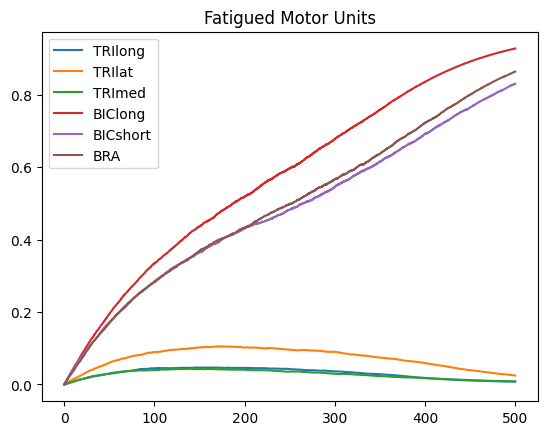

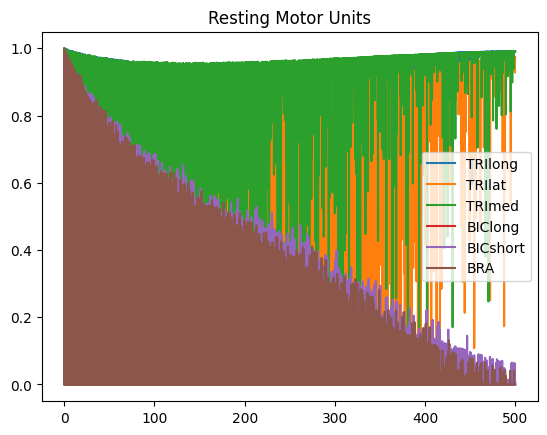

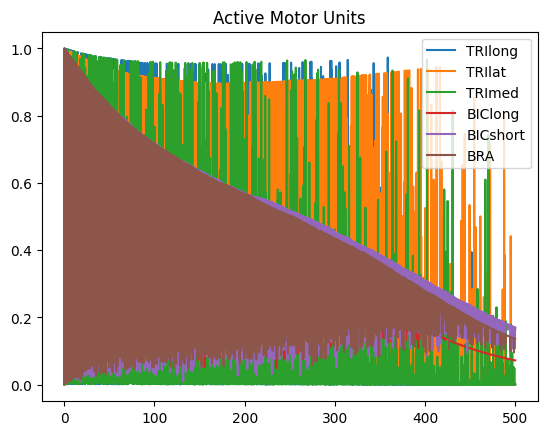

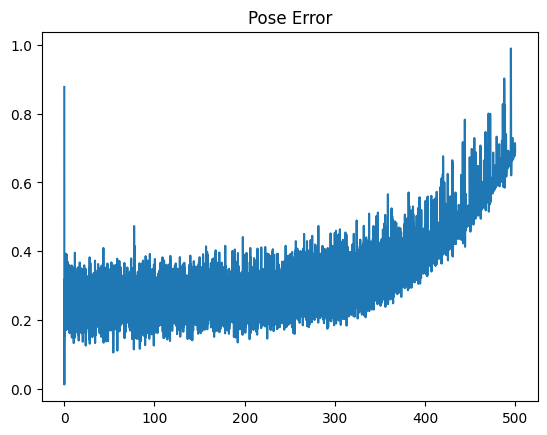

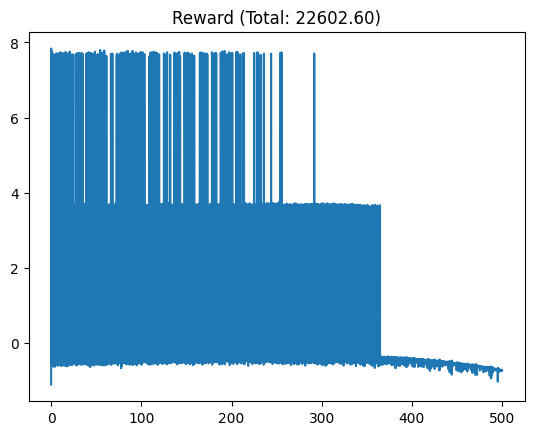

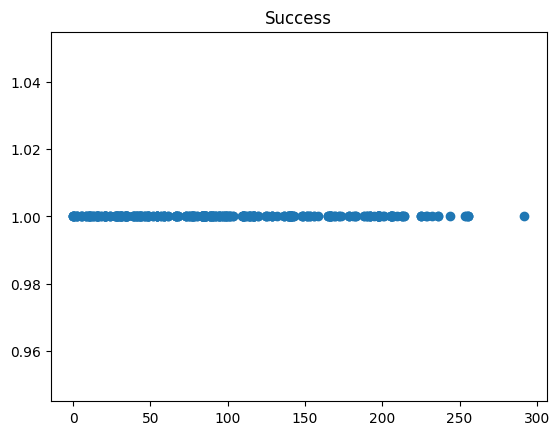

In [14]:
env_name = "myoFatiElbowPose1D6MRandom-v0"

####################

data_path = f"{env_name}/logs/fatitest.npy"
if not os.path.exists(data_path):
    print("No fatitest.npy; run previous cell with a trained model first.")
else:
    env_test = gym.make(env_name, normalize_act=False)
    mdl = env_test.unwrapped.mj_model
    muscle_names = [mdl.actuator(i).name for i in range(mdl.nu) if mdl.actuator_dyntype[i] == mujoco.mjtDyn.mjDYN_MUSCLE]
    _env_dt = env_test.unwrapped.dt  #0.02

    data_store = np.load(data_path, allow_pickle=True)

    plt.figure()
    for _muscleid in range(len(data_store[0]['MF'])):
        plt.plot(_env_dt*np.arange(len(data_store)), np.array([d['MF'][_muscleid] for d in data_store]), label=muscle_names[_muscleid])
    plt.legend()
    plt.title('Fatigued Motor Units')

    plt.figure()
    for _muscleid in range(len(data_store[0]['MR'])):
        plt.plot(_env_dt*np.arange(len(data_store)), np.array([d['MR'][_muscleid] for d in data_store]), label=muscle_names[_muscleid])
    plt.legend()
    plt.title('Resting Motor Units')

    plt.figure()
    for _muscleid in range(len(data_store[0]['MA'])):
        plt.plot(_env_dt*np.arange(len(data_store)), np.array([d['MA'][_muscleid] for d in data_store]), label=muscle_names[_muscleid])
    plt.legend()
    plt.title('Active Motor Units')

    plt.figure()
    plt.plot(_env_dt*np.arange(len(data_store)), np.array([np.linalg.norm(d['pose_err']) for d in data_store])), plt.title('Pose Error')

    plt.figure()
    plt.plot(_env_dt*np.arange(len(data_store)), np.array([d['reward'] for d in data_store])), plt.title(f"Reward (Total: {np.array([d['reward'] for d in data_store]).sum():.2f})")

    if "solved" in data_store[0]:
        plt.figure()
        plt.scatter(_env_dt*np.arange(len(data_store))[np.array([d['solved'] for d in data_store])], np.array([d['solved'] for d in data_store])[np.array([d['solved'] for d in data_store])]), plt.title(f"Success")

    print(f"Muscle Fatigue Equilibrium: {data_store[-1]['MF']}")

Comparison: Policy trained without fatigue

### Example 2: Fatigue + Resting Period

In this variant, the same target needs to be reached for 5 minutes, followed by a resting period of 2:30 minutes, and another 2:30 minutes of the same task.

In [15]:
env_name = "myoFatiElbowPose1D6MRandom-v0"

GENERATE_VIDEO = True
GENERATE_VIDEO_EPS = 300  #number of episodes that are rendered BOTH at the beginning (i.e., without fatigue) and at the end (i.e., with fatigue)

STORE_DATA = True  #store collected data from evaluation run in .npy file
n_eps = 300

###################################

env = gym.make(env_name)

model_path = f"{env_name}/iterations/rl_model_200000_steps.zip"
if not os.path.exists(model_path):
    print("PPO model not found; skipping evaluation.")
    env.close()
else:
    from stable_baselines3 import PPO
    model = PPO.load(f"{env_name}/iterations/rl_model_200000_steps")

    env.unwrapped.set_fatigue_reset_random(False)
    env.unwrapped.reset(fatigue_reset=True)  #ensure that fatigue is reset before the simulation starts

    env.unwrapped.mj_model.cam_poscom0[0]= np.array([-1.3955, -0.3287,  0.6579])

    data_store = []
    if GENERATE_VIDEO:
        frames = []

    env.unwrapped.target_jnt_value = env.unwrapped.target_jnt_range[:, 1]
    env.unwrapped.target_type = 'fixed'
    env.unwrapped.update_target(restore_sim=True)

    start_time = time.time()
    for ep in range(n_eps):
        print("Ep {} of {}".format(ep, n_eps))

        for _cstep in range(env.spec.max_episode_steps):
            if GENERATE_VIDEO and (ep in range(GENERATE_VIDEO_EPS) or ep in range(n_eps-GENERATE_VIDEO_EPS, n_eps)):
                frame = env.unwrapped.mj_renderer.render_offscreen(width=480, height=480, camera_id=0)

                # Add text overlay
                _current_time = (ep*env.spec.max_episode_steps + _cstep)*env.unwrapped.dt
                frame = np.array(add_text_to_frame(frame,
                        f"t={str(int(_current_time//60)).zfill(2)}:{str(int(_current_time%60)).zfill(2)}min",
                        pos=(365, 3), color=(0, 0, 0), fontsize=18))

                if ep >= n_eps*0.5 and ep < n_eps*0.75:
                    frame = np.array(add_text_to_frame(frame,
                        f"Resting Phase",
                        pos=(320, 450), color=(84, 184, 81), fontsize=18))

                if _cstep % 10 == 0:  #append video frame every 10 steps to reduce video size
                    frames.append(frame)
            o = env.unwrapped.get_obs()
            a = model.predict(o)[0]

            if ep >= n_eps*0.5 and ep < n_eps*0.75:
                a[:] = -100000  #resting period (corresponds to zero muscle activations)
                env.unwrapped.mj_model.site_rgba[env.unwrapped.target_sids[0]][-1] = 0  #hide target during resting period
                env.unwrapped.mj_model.tendon_rgba[-1][-1] = 0  #hide error line during resting period
            else:
                env.unwrapped.mj_model.site_rgba[env.unwrapped.target_sids[0]][-1] = 0.2  #visualise target during task
                env.unwrapped.mj_model.tendon_rgba[-1][-1] = 0.2  #visualise error line during task

            next_o, r, done, _, ifo = env.unwrapped.step(a) # take an action based on the current observation

            data_store.append({"action":a.copy(),
                                "jpos":env.unwrapped.mj_data.qpos.copy(),
                                "mlen":env.unwrapped.mj_data.actuator_length.copy(),
                                "act":env.unwrapped.mj_data.act.copy(),
                                "reward":r,
                                "solved":env.unwrapped.rwd_dict['solved'].item(),
                                "pose_err":env.unwrapped.get_obs_dict(env.unwrapped.mj_model, env.unwrapped.mj_data)["pose_err"],
                                "MA":env.unwrapped.muscle_fatigue.MA.copy(),
                                "MR":env.unwrapped.muscle_fatigue.MR.copy(),
                                "MF":env.unwrapped.muscle_fatigue.MF.copy(),
                                "ctrl":env.unwrapped.last_ctrl.copy()})
    env.close()

    ## OPTIONALLY: Stored simulated data
    if STORE_DATA:
        os.makedirs(f"{env_name}/logs", exist_ok=True)
        np.save(f"{env_name}/logs/fatitest_recovery.npy", data_store)

    ## OPTIONALLY: Render video
    if GENERATE_VIDEO:
        os.makedirs(f'{env_name}/videos', exist_ok=True)    # Write video using ffmpeg
        # Write frames to file
        with imageio.get_writer(f'{env_name}/videos/fatitest_recovery.mp4', fps=int(1/env.unwrapped.dt)) as video:
            for frame in frames:
                video.append_data(frame)

    end_time = time.time()
    print(f"DURATION: {end_time - start_time:.2f}s")

    if GENERATE_VIDEO:
        display(show_video(f'{env_name}/videos/fatitest_recovery.mp4'))

Ep 0 of 300
Ep 1 of 300
Ep 2 of 300
Ep 3 of 300
Ep 4 of 300
Ep 5 of 300
Ep 6 of 300
Ep 7 of 300
Ep 8 of 300
Ep 9 of 300
Ep 10 of 300
Ep 11 of 300
Ep 12 of 300
Ep 13 of 300
Ep 14 of 300
Ep 15 of 300
Ep 16 of 300
Ep 17 of 300
Ep 18 of 300
Ep 19 of 300
Ep 20 of 300
Ep 21 of 300
Ep 22 of 300
Ep 23 of 300
Ep 24 of 300
Ep 25 of 300
Ep 26 of 300
Ep 27 of 300
Ep 28 of 300
Ep 29 of 300
Ep 30 of 300
Ep 31 of 300
Ep 32 of 300
Ep 33 of 300
Ep 34 of 300
Ep 35 of 300
Ep 36 of 300
Ep 37 of 300
Ep 38 of 300
Ep 39 of 300
Ep 40 of 300
Ep 41 of 300
Ep 42 of 300
Ep 43 of 300
Ep 44 of 300
Ep 45 of 300
Ep 46 of 300
Ep 47 of 300
Ep 48 of 300
Ep 49 of 300
Ep 50 of 300
Ep 51 of 300
Ep 52 of 300
Ep 53 of 300
Ep 54 of 300
Ep 55 of 300
Ep 56 of 300
Ep 57 of 300
Ep 58 of 300
Ep 59 of 300
Ep 60 of 300
Ep 61 of 300
Ep 62 of 300
Ep 63 of 300
Ep 64 of 300
Ep 65 of 300
Ep 66 of 300
Ep 67 of 300
Ep 68 of 300
Ep 69 of 300
Ep 70 of 300
Ep 71 of 300
Ep 72 of 300
Ep 73 of 300
Ep 74 of 300
Ep 75 of 300
Ep 76 of 300
Ep 77 of 

/scratch/fjf33/myosuite/myosuite/envs/myo/base_v0.py:89: RuntimeWarning: overflow encountered in exp
  1.0 + np.exp(-5.0 * (muscle_a[muscle_act_ind] - 0.5))


Ep 151 of 300
Ep 152 of 300
Ep 153 of 300
Ep 154 of 300
Ep 155 of 300
Ep 156 of 300
Ep 157 of 300
Ep 158 of 300
Ep 159 of 300
Ep 160 of 300
Ep 161 of 300
Ep 162 of 300
Ep 163 of 300
Ep 164 of 300
Ep 165 of 300
Ep 166 of 300
Ep 167 of 300
Ep 168 of 300
Ep 169 of 300
Ep 170 of 300
Ep 171 of 300
Ep 172 of 300
Ep 173 of 300
Ep 174 of 300
Ep 175 of 300
Ep 176 of 300
Ep 177 of 300
Ep 178 of 300
Ep 179 of 300
Ep 180 of 300
Ep 181 of 300
Ep 182 of 300
Ep 183 of 300
Ep 184 of 300
Ep 185 of 300
Ep 186 of 300
Ep 187 of 300
Ep 188 of 300
Ep 189 of 300
Ep 190 of 300
Ep 191 of 300
Ep 192 of 300
Ep 193 of 300
Ep 194 of 300
Ep 195 of 300
Ep 196 of 300
Ep 197 of 300
Ep 198 of 300
Ep 199 of 300
Ep 200 of 300
Ep 201 of 300
Ep 202 of 300
Ep 203 of 300
Ep 204 of 300
Ep 205 of 300
Ep 206 of 300
Ep 207 of 300
Ep 208 of 300
Ep 209 of 300
Ep 210 of 300
Ep 211 of 300
Ep 212 of 300
Ep 213 of 300
Ep 214 of 300
Ep 215 of 300
Ep 216 of 300
Ep 217 of 300
Ep 218 of 300
Ep 219 of 300
Ep 220 of 300
Ep 221 of 300
Ep 222

Muscle Fatigue Equilibrium: [0.0452 0.0992 0.0417 0.4675 0.3876 0.3888]


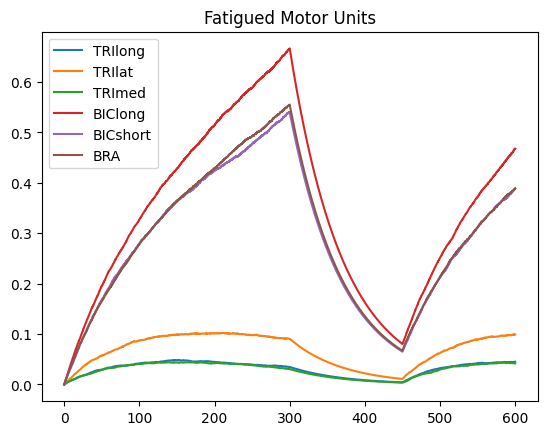

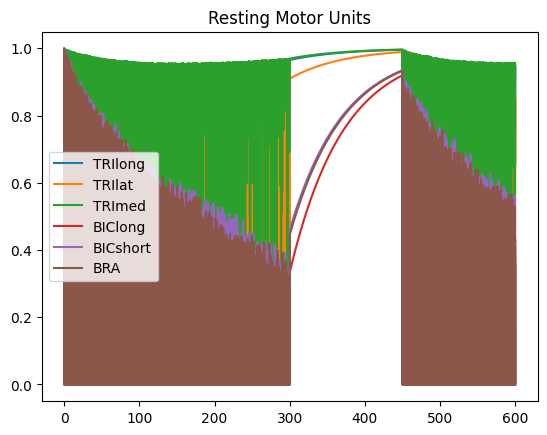

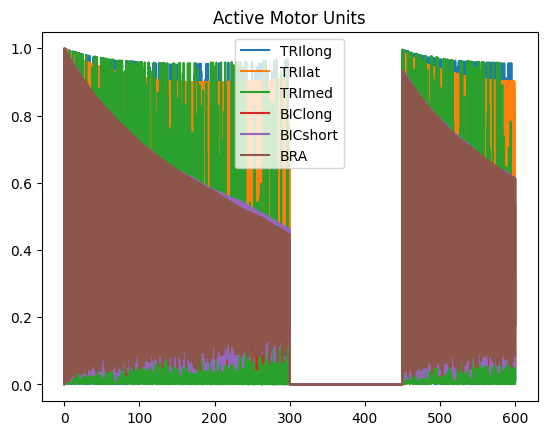

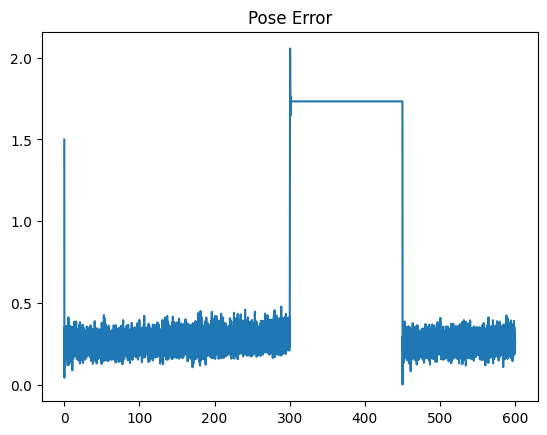

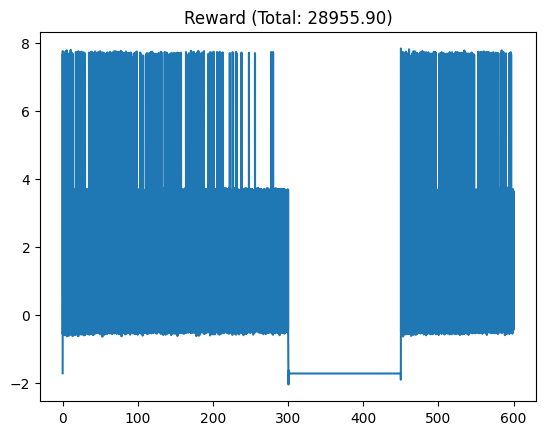

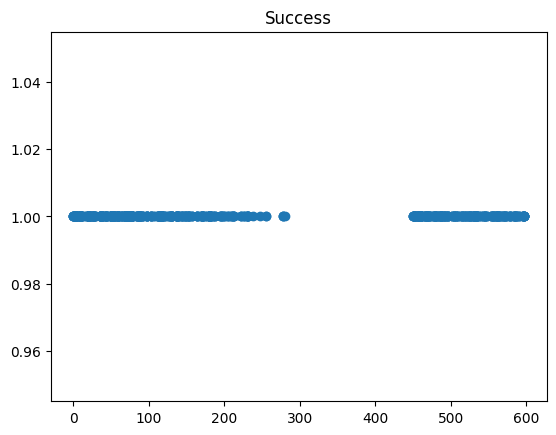

In [16]:
env_name = "myoFatiElbowPose1D6MRandom-v0"

####################

data_path = f"{env_name}/logs/fatitest_recovery.npy"
if not os.path.exists(data_path):
    print("No fatitest_recovery.npy; run previous cell (Example 2) with a trained model first.")
else:
    env_test = gym.make(env_name, normalize_act=False)
    mdl = env_test.unwrapped.mj_model
    muscle_names = [mdl.actuator(i).name for i in range(mdl.nu) if mdl.actuator_dyntype[i] == mujoco.mjtDyn.mjDYN_MUSCLE]
    _env_dt = env_test.unwrapped.dt  #0.02

    data_store = np.load(data_path, allow_pickle=True)

    plt.figure()
    for _muscleid in range(len(data_store[0]['MF'])):
        plt.plot(_env_dt*np.arange(len(data_store)), np.array([d['MF'][_muscleid] for d in data_store]), label=muscle_names[_muscleid])
    plt.legend()
    plt.title('Fatigued Motor Units')

    plt.figure()
    for _muscleid in range(len(data_store[0]['MR'])):
        plt.plot(_env_dt*np.arange(len(data_store)), np.array([d['MR'][_muscleid] for d in data_store]), label=muscle_names[_muscleid])
    plt.legend()
    plt.title('Resting Motor Units')

    plt.figure()
    for _muscleid in range(len(data_store[0]['MA'])):
        plt.plot(_env_dt*np.arange(len(data_store)), np.array([d['MA'][_muscleid] for d in data_store]), label=muscle_names[_muscleid])
    plt.legend()
    plt.title('Active Motor Units')

    plt.figure()
    plt.plot(_env_dt*np.arange(len(data_store)), np.array([np.linalg.norm(d['pose_err']) for d in data_store])), plt.title('Pose Error')

    plt.figure()
    plt.plot(_env_dt*np.arange(len(data_store)), np.array([d['reward'] for d in data_store])), plt.title(f"Reward (Total: {np.array([d['reward'] for d in data_store]).sum():.2f})")

    if "solved" in data_store[0]:
        plt.figure()
        plt.scatter(_env_dt*np.arange(len(data_store))[np.array([d['solved'] for d in data_store])], np.array([d['solved'] for d in data_store])[np.array([d['solved'] for d in data_store])]), plt.title(f"Success")

    print(f"Muscle Fatigue Equilibrium: {data_store[-1]['MF']}")